In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import math
from tqdm import tqdm

In [2]:
language="hindi"

corpus_file = f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{language}_processed.txt"

In [3]:
def load_and_tokenize_corpus(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        print(f"Loaded {len(words):,} words, {len(set(words)):,} unique words")
        return words
    
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return []
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return []


In [4]:

def compute_vocabulary_growth(words, sample_points):
    
    total_tokens = len(words)
    step_size = max(1, total_tokens // sample_points)
    
    corpus_sizes = []
    vocabulary_sizes = []
    vocabulary = set()
    
    print(f"Computing vocabulary growth for {total_tokens:,} tokens...")
    
    for i in tqdm(range(len(words))):
        word = words[i]
        vocabulary.add(word)
        
        if i % step_size == 0 or i == total_tokens - 1:
            corpus_sizes.append(i + 1)
            vocabulary_sizes.append(len(vocabulary))
    
    return np.array(corpus_sizes), np.array(vocabulary_sizes)


In [5]:


def heaps_law(N, K, beta):
    return K * (N ** beta)

def fit_heaps_law(corpus_sizes, vocabulary_sizes):
    
    try:
        # Use nonlinear least squares to fit Heaps' law
        def heaps_wrapper(N, K, beta):
            return heaps_law(N, K, beta)
        
        # Initial guesses: K around 10-100, beta around 0.5-0.7 (typical values)
        initial_guess = [50.0, 0.5]
        
        # Fit the model
        params, _ = curve_fit(heaps_wrapper, corpus_sizes, vocabulary_sizes, 
                             p0=initial_guess, maxfev=5000)
        
        K, beta = params
        
        # Calculate predictions and metrics
        predictions = heaps_law(corpus_sizes, K, beta)
        
        
        r2 = r2_score(vocabulary_sizes, predictions)
        mse = mean_squared_error(vocabulary_sizes, predictions)
        rmse = np.sqrt(mse)
        
        return {
            'K': K,
            'beta': beta,
            'r2': r2,
            'mse': mse,
            'rmse': rmse,
            'predictions': predictions
        }
        
    except Exception as e:
        print(f"Error fitting Heaps' law: {e}")
        return None


In [ ]:

def plot_heaps_law(corpus_sizes, vocabulary_sizes, heaps_results, language="Hindi"):
    
    plt.figure(figsize=(12, 8))
    
    # Plot actual data
    plt.plot(corpus_sizes, vocabulary_sizes, 'o', markersize=4, alpha=0.7, 
              label='Actual Vocabulary Growth')
    
    # Plot fitted Heaps' law
    if heaps_results:
        plt.plot(corpus_sizes, heaps_results['predictions'], 'r-', linewidth=2,
                  label=f"Heaps' Law Fit (K={heaps_results['K']:.2f}, β={heaps_results['beta']:.3f}")
    
    plt.xlabel('Corpus Size (Number of Tokens)')
    plt.ylabel('Vocabulary Size (Number of Unique Words)')
    plt.title(f'Heaps\' Law - Vocabulary Growth for {language} Corpus')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [7]:

def analyze_heaps_law(corpus_file_path, language="NA", sample_points_percentage=0.05):
    
    print(f"Starting Heaps' Law Analysis for {language}")
    print("=" * 50)
    
    # Load and tokenize corpus
    words = load_and_tokenize_corpus(corpus_file_path)
    if not words:
        return None
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = compute_vocabulary_growth(words, sample_points_percentage*len(words))
    
    # Fit Heaps' law
    heaps_results = fit_heaps_law(corpus_sizes, vocabulary_sizes)
    
    if heaps_results:
        # Plot results
        plot_heaps_law(corpus_sizes, vocabulary_sizes, heaps_results, language)
        
        # Print results
        print("\nHEAPS' LAW PARAMETERS:")
        print("=" * 30)
        print(f"K parameter: {heaps_results['K']:.4f}")
        print(f"β parameter: {heaps_results['beta']:.4f}")
        print(f"R² score: {heaps_results['r2']:.4f}")
        print(f"MSE: {heaps_results['mse']:.4f}")
        print(f"RMSE: {heaps_results['rmse']:.4f}")
    
    return heaps_results



HEAPS' LAW ANALYSIS
Starting Heaps' Law Analysis for hindi
Loaded 88,757,626 words, 868,332 unique words
Computing vocabulary growth for 88,757,626 tokens...


100%|██████████| 88757626/88757626 [00:12<00:00, 7043794.26it/s]


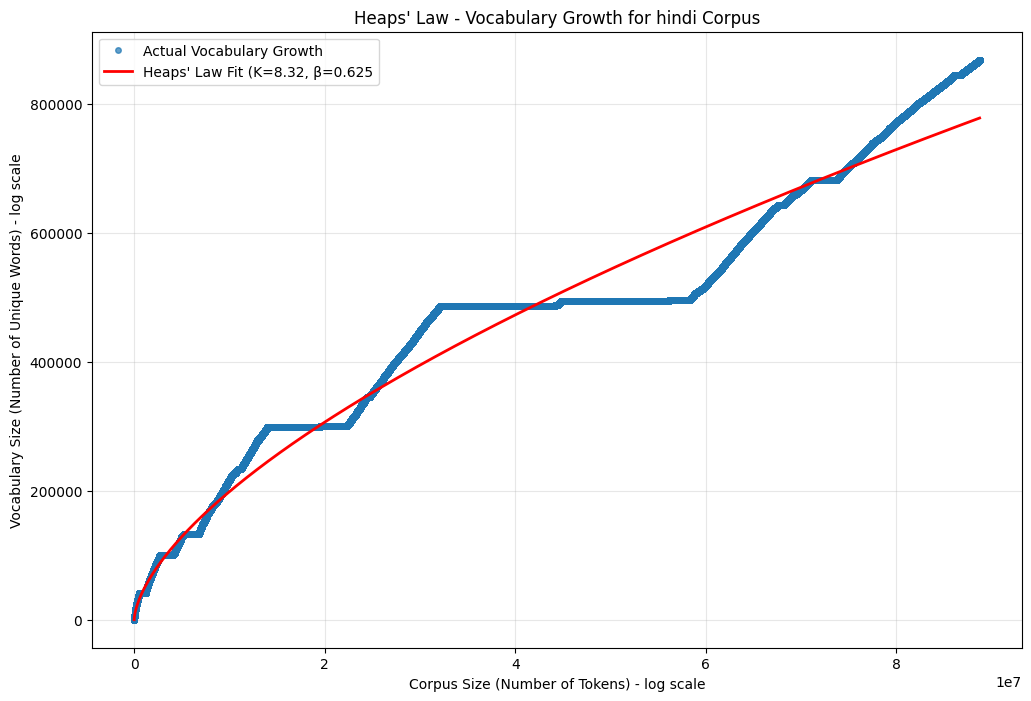


HEAPS' LAW PARAMETERS:
K parameter: 8.3247
β parameter: 0.6254
R² score: 0.9492
MSE: 2076289206.2174
RMSE: 45566.3166


In [8]:
print("\n" + "="*60)
print("HEAPS' LAW ANALYSIS")
print("="*60)
heaps_results = analyze_heaps_law(corpus_file, language=language)